# 01 — Data Exploration

Validate the raw data from both sources (Pilafas KenPom + March ML Mania), test the data layer loaders, inspect schemas, check merge quality, and spot-check against known tournament results.

In [4]:
import sys
sys.path.insert(0, "..")

import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(level=logging.INFO)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## 1. Load KenPom Data

In [5]:
from src.data.kaggle_loader import load_kenpom

kenpom = load_kenpom()
print(f"Shape: {kenpom.shape}")
print(f"Seasons: {kenpom['season'].min()} – {kenpom['season'].max()}")
print(f"Teams per season (2025): {len(kenpom[kenpom['season']==2025])}")
kenpom.head()

INFO:src.data.kaggle_loader:Loading DEV table from /Users/austinsalter/Documents/Projects/March Madness MOE/data/raw/kenpom/DEV _ March Madness.csv
INFO:src.data.kaggle_loader:Loaded DEV table: 8315 rows, 24 seasons (2002–2025), 38 columns
INFO:src.data.kaggle_loader:INT four factors loaded: 9268 rows
INFO:src.data.kaggle_loader:Final KenPom dataset: 8315 rows, 38 columns, seasons 2002–2025


Shape: (8315, 38)
Seasons: 2002 – 2025
Teams per season (2025): 364


,season,conf,off_efgpct,off_topct,off_orpct,off_ftrate,adjtempo,adjoe,adjde,adjem,rank,off_fg2pct,off_fg3pct,off_ftpct,off_blockpct,def_fg2pct,def_fg3pct,def_ftpct,def_blockpct,off_fg3rate,def_fg3rate,off_arate,def_arate,off_stlrate,def_stlrate,off_nstrate,def_nstrate,avg_height,eff_height,experience,bench,net_rating,conf_full,team,full_team_name,ncaa_seed,ncaa_region,postseason
0,2002,MWC,55.3432,23.0417,21.9373,40.3997,53.9623,103.4960,104.9860,-1.49060,178.0,54.8061,37.2760,71.1828,6.8287,53.2407,32.6761,71.1599,12.3103,48.4796,29.1222,61.3508,47.3958,0.1412,0.1084,NaN,NaN,NaN,NaN,NaN,NaN,-1.7,Mountain West Conference (MW),Air Force,Air Force Falcons,Not In a Post-Season Tournament,Not In a Post-Season Tournament,Not In a Post-Season Tournament
1,2002,MAC,50.6854,21.2202,30.1724,45.2350,65.4218,104.7520,111.0060,-6.25413,229.0,48.4271,37.0600,75.7576,6.9726,52.4272,35.5357,71.1569,10.7722,31.5274,33.0774,57.3508,55.3594,0.0868,0.1140,NaN,NaN,NaN,NaN,NaN,NaN,-6.0,Mid-American Conference (MAC),Akron,Akron Zips,Not In a Post-Season Tournament,Not In a Post-Season Tournament,Not In a Post-Season Tournament
2,2002,SEC,49.1791,20.0267,40.1736,40.7533,67.8101,114.1770,94.1585,20.01810,16.0,50.6579,30.8677,73.5782,8.0468,45.2085,31.7841,68.2422,7.1637,33.9450,32.7925,50.5495,46.9880,0.1053,0.0881,NaN,NaN,NaN,NaN,NaN,NaN,18.7,Southeastern Conference (SEC),Alabama,Alabama Crimson Tide,2,South,March Madness
3,2002,SWAC,45.3408,21.0951,38.3031,35.3568,78.7250,91.9307,101.3140,-9.38333,261.0,44.2636,31.5871,66.4157,9.4669,49.2647,31.0078,59.7074,8.2994,34.5580,32.1696,52.7370,52.4425,0.1665,0.1039,NaN,NaN,NaN,NaN,NaN,NaN,-9.5,Southwestern Conference (SWC),Alabama A&M,Alabama A&M Bulldogs,Not In a Post-Season Tournament,Not In a Post-Season Tournament,Not In a Post-Season Tournament
4,2002,SWAC,47.2716,23.9665,34.3045,45.6853,62.8315,89.8764,102.3500,-12.47340,272.0,45.8801,33.4646,64.4444,5.7722,44.9298,32.0542,67.6864,9.6442,32.2335,25.6812,44.2424,48.7465,0.0985,0.1358,NaN,NaN,NaN,NaN,NaN,NaN,-12.6,Southwestern Conference (SWC),Alabama State,Alabama State Hornets,Not In a Post-Season Tournament,Not In a Post-Season Tournament,Not In a Post-Season Tournament


In [6]:
# Column types and missing values
kenpom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8315 entries, 0 to 8314
Data columns (total 38 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          8315 non-null   int64  
 1   conf            8315 non-null   object 
 2   off_efgpct      8315 non-null   float64
 3   off_topct       8315 non-null   float64
 4   off_orpct       8315 non-null   float64
 5   off_ftrate      8315 non-null   float64
 6   adjtempo        8315 non-null   float64
 7   adjoe           8315 non-null   float64
 8   adjde           8315 non-null   float64
 9   adjem           8315 non-null   float64
 10  rank            8315 non-null   float64
 11  off_fg2pct      8315 non-null   float64
 12  off_fg3pct      8315 non-null   float64
 13  off_ftpct       8315 non-null   float64
 14  off_blockpct    8315 non-null   float64
 15  def_fg2pct      8315 non-null   float64
 16  def_fg3pct      8315 non-null   float64
 17  def_ftpct       8315 non-null   f

In [7]:
# Key metric distributions
key_metrics = ["adjem", "adjoe", "adjde", "adjtempo", "off_efgpct", "off_topct"]
kenpom[key_metrics].describe()

,adjem,adjoe,adjde,adjtempo,off_efgpct,off_topct
count,8315.000000,8315.000000,8315.000000,8315.000000,8315.000000,8315.000000
mean,-0.000161,103.540884,103.541036,66.369256,49.563806,19.695070
std,12.046497,7.476179,6.471788,3.293367,3.530120,3.779978
min,-46.268400,71.127100,81.318700,51.072000,0.000000,11.900000
25%,-8.625125,98.505000,99.114900,64.282250,47.567344,17.838118
50%,-0.778440,103.459000,103.755000,66.387400,49.626000,19.494800
75%,8.433735,108.578500,108.221500,68.526950,51.674950,21.264500
max,38.154400,128.600000,125.313000,89.217200,61.017812,100.000000


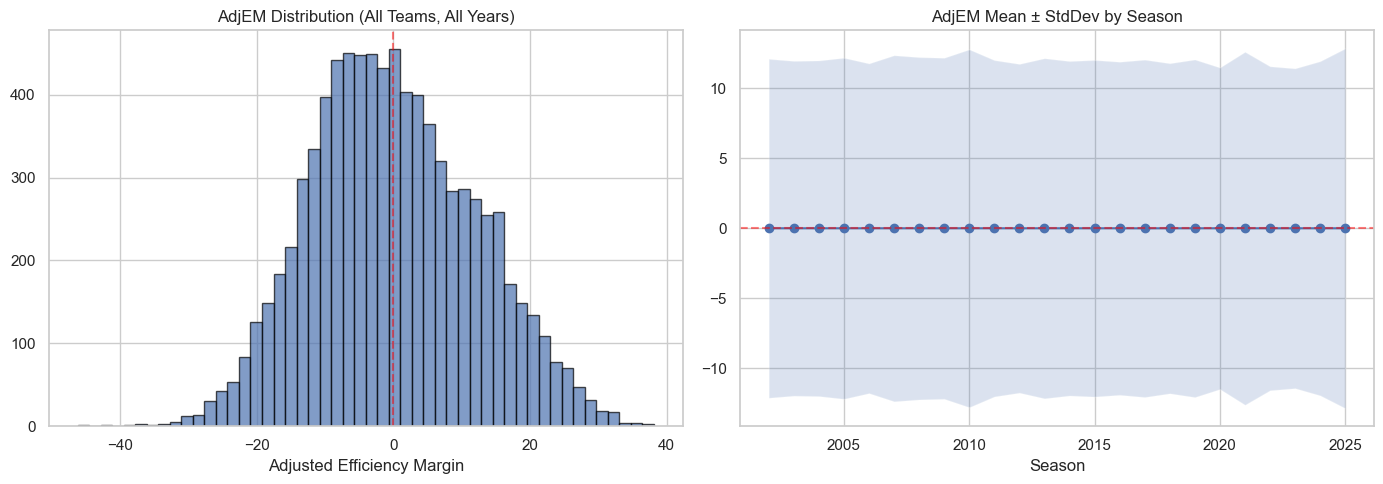

In [8]:
# AdjEM distribution by season — check for data consistency across years
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AdjEM distribution
kenpom["adjem"].hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_title("AdjEM Distribution (All Teams, All Years)")
axes[0].set_xlabel("Adjusted Efficiency Margin")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)

# AdjEM mean by season — should be ~0 each year
yearly = kenpom.groupby("season")["adjem"].agg(["mean", "std"])
yearly["mean"].plot(ax=axes[1], marker="o")
axes[1].fill_between(yearly.index, yearly["mean"] - yearly["std"], yearly["mean"] + yearly["std"], alpha=0.2)
axes[1].set_title("AdjEM Mean ± StdDev by Season")
axes[1].set_xlabel("Season")
axes[1].axhline(0, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 2. Load Tournament Matchups

In [9]:
from src.data.tournament_data import load_matchups

matchups = load_matchups()
print(f"Shape: {matchups.shape}")
print(f"Seasons: {matchups['season'].min()} – {matchups['season'].max()}")
print(f"Games per season: ~{len(matchups) // matchups['season'].nunique()}")
matchups.head(10)

INFO:src.data.tournament_data:Dropping 63 First Four / play-in games
INFO:src.data.tournament_data:Loaded 1386 tournament matchups across 22 seasons (2003–2025)


Shape: (1386, 12)
Seasons: 2003 – 2025
Games per season: ~63


,season,round,region,seed_a,team_id_a,team_name_a,score_a,seed_b,team_id_b,team_name_b,score_b,higher_seed_won
0,2003,1,Z,1,1112,Arizona,80,16,1436,Vermont,51,1
1,2003,1,W,1,1328,Oklahoma,71,16,1354,S Carolina St,54,1
2,2003,1,Y,1,1246,Kentucky,95,16,1237,IUPUI,64,1
3,2003,1,X,1,1400,Texas,82,16,1421,UNC Asheville,61,1
4,2003,1,Z,2,1242,Kansas,64,15,1429,Utah St,61,1
5,2003,1,X,2,1196,Florida,85,15,1358,Sam Houston St,55,1
6,2003,1,Y,2,1338,Pittsburgh,87,15,1447,Wagner,61,1
7,2003,1,W,2,1448,Wake Forest,76,15,1190,ETSU,73,1
8,2003,1,Z,3,1181,Duke,67,14,1161,Colorado St,57,1
9,2003,1,Y,3,1266,Marquette,72,14,1221,Holy Cross,68,1


In [10]:
# Games per round and higher seed win rate by round
round_stats = matchups.groupby("round").agg(
    games=("higher_seed_won", "count"),
    higher_seed_win_rate=("higher_seed_won", "mean"),
)
round_stats.index = ["R64", "R32", "S16", "E8", "F4", "Championship"]
round_stats

,games,higher_seed_win_rate
R64,704,0.732955
R32,352,0.721591
S16,176,0.687500
E8,88,0.534091
F4,44,0.704545
Championship,22,0.772727


In [11]:
# Upset rate by seed matchup (R64 only)
r64 = matchups[matchups["round"] == 1].copy()
r64["matchup"] = r64["seed_a"].astype(str) + " vs " + r64["seed_b"].astype(str)

upset_rates = r64.groupby("matchup").agg(
    games=("higher_seed_won", "count"),
    higher_seed_wins=("higher_seed_won", "sum"),
).assign(upset_rate=lambda df: 1 - df["higher_seed_wins"] / df["games"])
upset_rates = upset_rates.sort_values("upset_rate", ascending=False)
upset_rates

,games,higher_seed_wins,upset_rate
matchup,,,
11 vs 11,1,0,1.000000
8 vs 9,88,44,0.500000
6 vs 11,88,49,0.443182
5 vs 12,88,54,0.386364
7 vs 10,87,54,0.379310
4 vs 13,88,70,0.204545
3 vs 14,88,78,0.113636
2 vs 15,88,81,0.079545
1 vs 16,88,86,0.022727


## 3. Merge KenPom + Matchups

In [12]:
from src.data.merge import merge_kenpom_with_matchups

merged = merge_kenpom_with_matchups(kenpom, matchups)
print(f"Merged shape: {merged.shape}")
print(f"Missing stats: {merged['adjem_a'].isna().sum()} team_a, {merged['adjem_b'].isna().sum()} team_b")
merged.head()

INFO:src.data.merge:Merge complete: all 1389 games have KenPom stats for both teams


Merged shape: (1389, 70)
Missing stats: 0 team_a, 0 team_b


,season,round,region,seed_a,team_id_a,team_name_a,score_a,seed_b,team_id_b,team_name_b,score_b,higher_seed_won,off_efgpct_a,off_topct_a,off_orpct_a,off_ftrate_a,adjtempo_a,adjoe_a,adjde_a,adjem_a,off_fg2pct_a,off_fg3pct_a,off_ftpct_a,off_blockpct_a,def_fg2pct_a,...,adjtempo_b,adjoe_b,adjde_b,adjem_b,off_fg2pct_b,off_fg3pct_b,off_ftpct_b,off_blockpct_b,def_fg2pct_b,def_fg3pct_b,def_ftpct_b,def_blockpct_b,off_fg3rate_b,def_fg3rate_b,off_arate_b,def_arate_b,off_stlrate_b,def_stlrate_b,off_nstrate_b,def_nstrate_b,avg_height_b,eff_height_b,experience_b,bench_b,net_rating_b
0,2003,1,Z,1,1112,Arizona,80,16,1436,Vermont,51,1,51.4922,19.0144,39.2726,36.8072,73.0165,115.311,88.8866,26.4243,50.8186,35.3488,70.9138,9.5506,44.6629,...,64.3012,101.7230,99.8857,1.837600,48.0231,33.7634,65.9722,8.7512,47.0993,32.8173,67.5906,9.3081,27.6951,38.8455,57.1622,59.0449,0.1052,0.1087,NaN,NaN,NaN,NaN,NaN,NaN,1.6
1,2003,1,W,1,1328,Oklahoma,71,16,1354,S Carolina St,54,1,51.1506,18.6599,36.5739,32.9498,62.6863,112.913,89.4266,23.4861,47.3312,39.1850,69.2063,9.2620,44.4277,...,71.7419,96.5201,105.4380,-8.917540,50.3333,33.2645,69.9488,7.8345,45.6866,34.4037,65.3491,8.0833,28.7411,36.5363,41.3072,50.8065,0.1095,0.1335,NaN,NaN,NaN,NaN,NaN,NaN,-8.6
2,2003,1,Y,1,1246,Kentucky,95,16,1237,IUPUI,64,1,53.7583,20.0752,39.6918,35.2997,67.5518,116.802,87.0347,29.7672,53.9222,35.5556,70.3504,12.9412,45.2941,...,66.9628,103.0590,102.2980,0.761365,50.3401,34.7541,69.4040,5.0341,54.3515,36.3339,67.4380,10.6293,34.1545,34.2681,54.4776,62.5146,0.1178,0.0977,NaN,NaN,NaN,NaN,NaN,NaN,0.4
3,2003,1,X,1,1400,Texas,82,16,1421,UNC Asheville,61,1,49.3431,18.3702,41.5476,39.8054,69.0435,118.524,95.1369,23.3866,47.8405,35.6364,72.1271,8.7050,44.2446,...,67.6550,100.9430,114.3110,-13.368200,46.2687,35.6643,75.9690,7.4519,50.2404,36.8259,66.6667,10.3648,32.1710,34.2119,52.4934,56.6975,0.0990,0.1212,NaN,NaN,NaN,NaN,NaN,NaN,-12.3
4,2003,1,Z,2,1242,Kansas,64,15,1429,Utah St,61,1,52.6829,20.0666,39.5104,37.7384,72.6511,114.003,86.9009,27.1016,53.4790,33.3333,65.2174,11.4733,42.1773,...,61.2320,106.8600,100.1210,6.739110,49.3095,33.3333,72.1232,5.7331,48.3083,34.0509,69.3654,5.4427,23.6352,32.4444,58.5831,50.8721,0.0831,0.0831,NaN,NaN,NaN,NaN,NaN,NaN,7.4


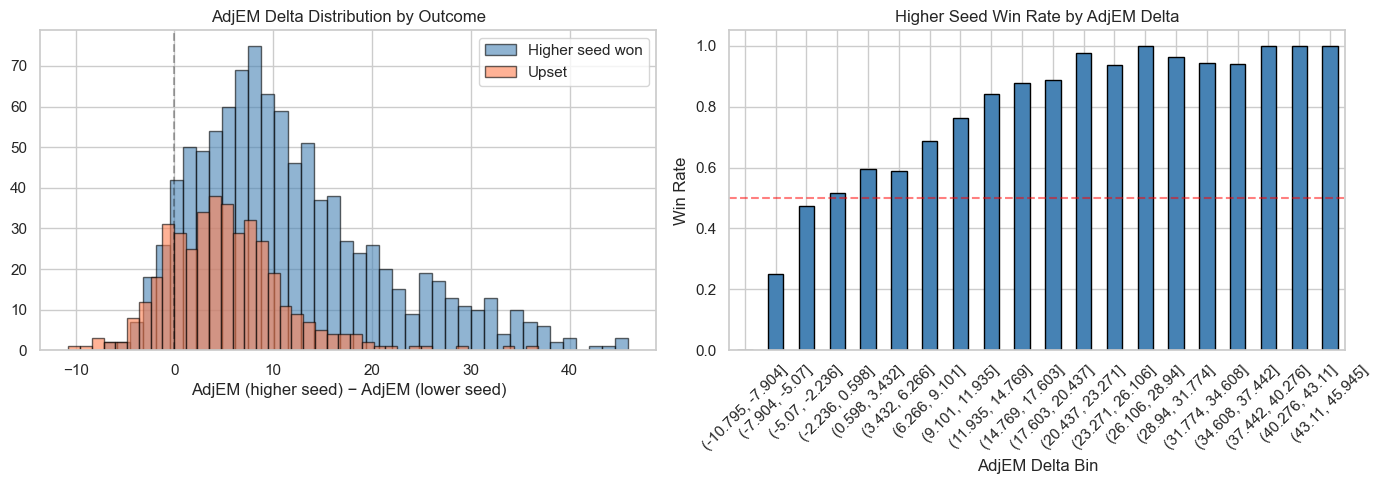

In [13]:
# AdjEM delta vs outcome — this should be the strongest single predictor
merged["adjem_delta"] = merged["adjem_a"] - merged["adjem_b"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of AdjEM delta by outcome
for won, label, color in [(1, "Higher seed won", "steelblue"), (0, "Upset", "coral")]:
    subset = merged[merged["higher_seed_won"] == won]
    axes[0].hist(subset["adjem_delta"], bins=40, alpha=0.6, label=label, color=color, edgecolor="black")
axes[0].set_title("AdjEM Delta Distribution by Outcome")
axes[0].set_xlabel("AdjEM (higher seed) − AdjEM (lower seed)")
axes[0].legend()
axes[0].axvline(0, color="black", linestyle="--", alpha=0.3)

# Win rate by AdjEM delta bin
merged["adjem_delta_bin"] = pd.cut(merged["adjem_delta"], bins=20)
bin_rates = merged.groupby("adjem_delta_bin", observed=True)["higher_seed_won"].mean()
bin_rates.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Higher Seed Win Rate by AdjEM Delta")
axes[1].set_ylabel("Win Rate")
axes[1].set_xlabel("AdjEM Delta Bin")
axes[1].axhline(0.5, color="red", linestyle="--", alpha=0.5)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 4. Spot Checks

Validate against known tournament results to ensure data integrity.

In [14]:
# Spot check known results
checks = [
    (2018, "Virginia", "UMBC", 1, 16, 0, "1-seed upset"),
    (2023, "Connecticut", "San Diego St", 4, 5, 1, "UConn title"),
    (2024, "Connecticut", "Purdue", 1, 1, 1, "UConn repeat"),
    (2025, "Florida", "Houston", 1, 1, 1, "Florida title"),
]

for yr, team_a_expected, team_b_expected, seed_a, seed_b, won_expected, label in checks:
    game = merged[(merged["season"] == yr) & (merged["round"] == 6)]
    if game.empty:
        game = merged[(merged["season"] == yr) & (merged["team_name_a"].str.contains(team_a_expected[:5], na=False))]
    if game.empty:
        print(f"❌ {yr} {label}: NOT FOUND")
        continue
    g = game.iloc[0]
    status = "✅" if g["higher_seed_won"] == won_expected else "❌"
    print(f"{status} {yr} {label}: {g['team_name_a']} ({g['seed_a']}) vs {g['team_name_b']} ({g['seed_b']}) → higher_seed_won={g['higher_seed_won']}")

❌ 2018 1-seed upset: Villanova (1) vs Michigan (3) → higher_seed_won=1
✅ 2023 UConn title: Connecticut (4) vs San Diego St (5) → higher_seed_won=1
✅ 2024 UConn repeat: Connecticut (1) vs Purdue (1) → higher_seed_won=1
✅ 2025 Florida title: Florida (1) vs Houston (1) → higher_seed_won=1


## 5. Feature Correlation Preview

Quick look at which KenPom metrics correlate most with `higher_seed_won`.

In [15]:
# Compute deltas (higher seed - lower seed) for all numeric KenPom columns
stat_cols_a = [c for c in merged.columns if c.endswith("_a") and merged[c].dtype in ["float64", "int64"]]
stat_names = [c[:-2] for c in stat_cols_a]

deltas = pd.DataFrame()
for name in stat_names:
    col_a, col_b = f"{name}_a", f"{name}_b"
    if col_a in merged.columns and col_b in merged.columns:
        deltas[f"{name}_delta"] = merged[col_a] - merged[col_b]

deltas["higher_seed_won"] = merged["higher_seed_won"].values
deltas["seed_diff"] = merged["seed_a"] - merged["seed_b"]

# Correlation with outcome
corrs = deltas.corr()["higher_seed_won"].drop("higher_seed_won").sort_values()
print("Top correlations with higher_seed_won:")
print(corrs.head(10).to_string())
print()
print(corrs.tail(10).to_string())

Top correlations with higher_seed_won:
seed_delta          -0.282459
seed_diff           -0.282459
adjde_delta         -0.210449
off_topct_delta     -0.130710
def_fg3pct_delta    -0.129421
def_nstrate_delta   -0.107189
off_nstrate_delta   -0.105900
def_stlrate_delta   -0.084503
def_fg2pct_delta    -0.080509
bench_delta         -0.072329

eff_height_delta      0.076959
off_fg2pct_delta      0.086292
off_blockpct_delta    0.089700
off_orpct_delta       0.090440
avg_height_delta      0.098786
off_efgpct_delta      0.099008
adjoe_delta           0.249953
adjem_delta           0.322797
net_rating_delta      0.418672
score_delta           0.756168


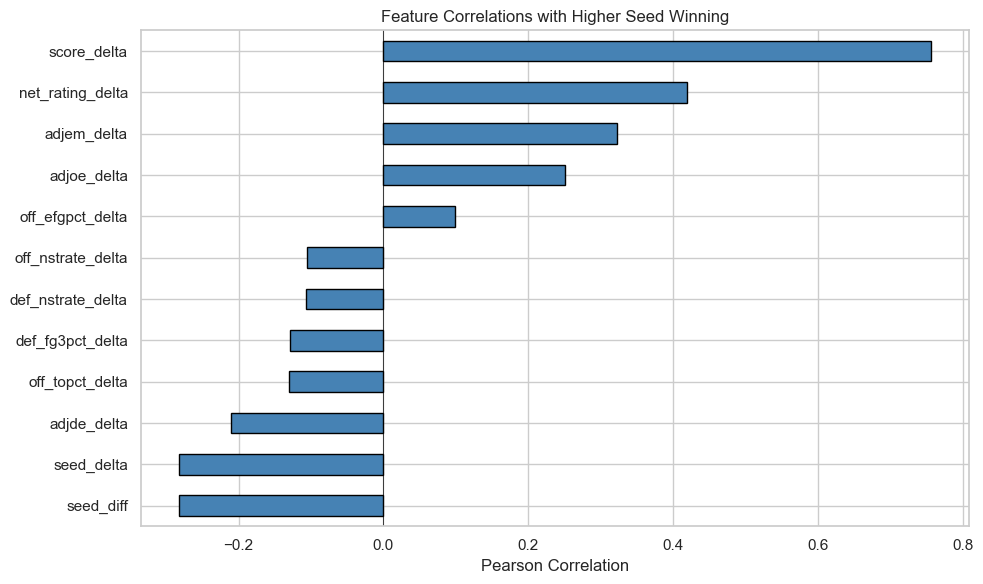

In [16]:
# Visualize top correlated features
top_features = corrs.abs().sort_values(ascending=False).head(12).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
corrs[top_features].sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Feature Correlations with Higher Seed Winning")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()